In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc, classification_report
import joblib
import warnings
warnings.filterwarnings('ignore')

In [2]:
BASE_PATH = r"c:\Users\santi\OneDrive\Desktop\9no Cuatri\Base de Datos\Conjunto de datos para 2a. evaluación-20260813"
# Carga de datos
ruta_cancer = os.path.join(BASE_PATH, 'breast-cancer.csv')
df_cancer = pd.read_csv(ruta_cancer)

In [3]:
# Exploración inicial
print("--- Forma del Dataset ---")
print(f"Filas: {df_cancer.shape[0]}, Columnas: {df_cancer.shape[1]}")

--- Forma del Dataset ---
Filas: 569, Columnas: 32


In [4]:
# Eliminamos la columna 'id' ya que no aporta valor predictivo
df_cancer.drop('id', axis=1, inplace=True)
# Revisamos balance de clases
print("\n--- Balance de la variable 'diagnosis' ---")
print(df_cancer['diagnosis'].value_counts(normalize=True) * 100)


--- Balance de la variable 'diagnosis' ---
diagnosis
B    62.741652
M    37.258348
Name: proportion, dtype: float64


In [5]:
print("\n--- Valores Nulos ---")
print("Total nulos en el dataset:", df_cancer.isnull().sum().sum())


--- Valores Nulos ---
Total nulos en el dataset: 0


In [6]:
# Codificación: M (Maligno) = 1, B (Benigno) = 0
le = LabelEncoder()
df_cancer['diagnosis'] = le.fit_transform(df_cancer['diagnosis'])

In [7]:
X = df_cancer.drop('diagnosis', axis=1)
y = df_cancer['diagnosis']

In [8]:
# División estratificada (stratify=y)
# Es CRUCIAL estratificar aquí para mantener el mismo porcentaje de casos M y B
# tanto en el set de entrenamiento como en el de prueba, evitando desbalances.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [9]:
# Dado que usaremos Regresión Logística, es obligatorio escalar los datos numéricos
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [10]:
# Definimos el modelo base
log_reg = LogisticRegression(random_state=42, max_iter=1000)

In [11]:
# Hiperparámetros a buscar: 
# C = Inverso de la fuerza de regularización (menor C = mayor regularización)
# penalty = tipo de regularización
parametros = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l2']
}
grid_search = GridSearchCV(log_reg, parametros, cv=5, scoring='recall')
grid_search.fit(X_train_scaled, y_train)
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test_scaled)
y_prob = best_model.predict_proba(X_test_scaled)[:, 1]
print(f"Mejor parámetro C encontrado: {grid_search.best_params_['C']}")

Mejor parámetro C encontrado: 100


In [12]:
print("--- Métricas de Clasificación ---")
print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precisión: {precision_score(y_test, y_pred):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred):.4f}")
print(f"F1-Score : {f1_score(y_test, y_pred):.4f}")
print("\nReporte completo:")
print(classification_report(y_test, y_pred, target_names=['Benigno (0)', 'Maligno (1)']))

--- Métricas de Clasificación ---
Accuracy : 0.9474
Precisión: 0.9737
Recall   : 0.8810
F1-Score : 0.9250

Reporte completo:
              precision    recall  f1-score   support

 Benigno (0)       0.93      0.99      0.96        72
 Maligno (1)       0.97      0.88      0.93        42

    accuracy                           0.95       114
   macro avg       0.95      0.93      0.94       114
weighted avg       0.95      0.95      0.95       114



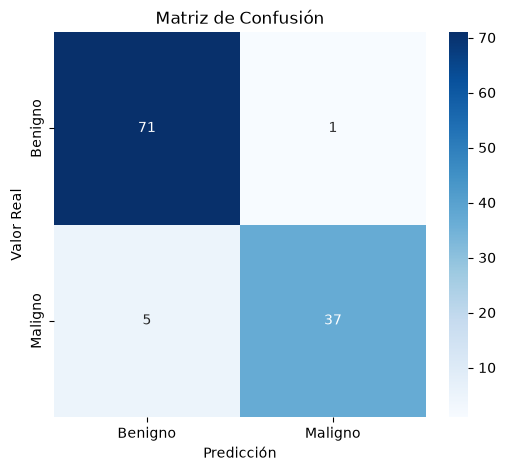

In [13]:
# 1. Matriz de Confusión
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Benigno', 'Maligno'], 
            yticklabels=['Benigno', 'Maligno'])
plt.title('Matriz de Confusión')
plt.ylabel('Valor Real')
plt.xlabel('Predicción')
plt.show()

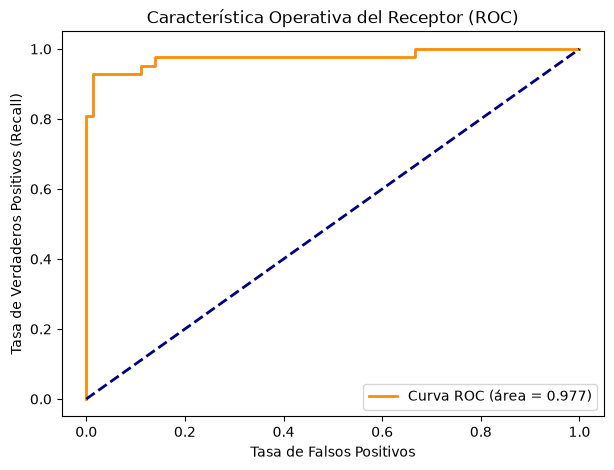

In [14]:
# 2. Curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Curva ROC (área = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos (Recall)')
plt.title('Característica Operativa del Receptor (ROC)')
plt.legend(loc="lower right")
plt.show()

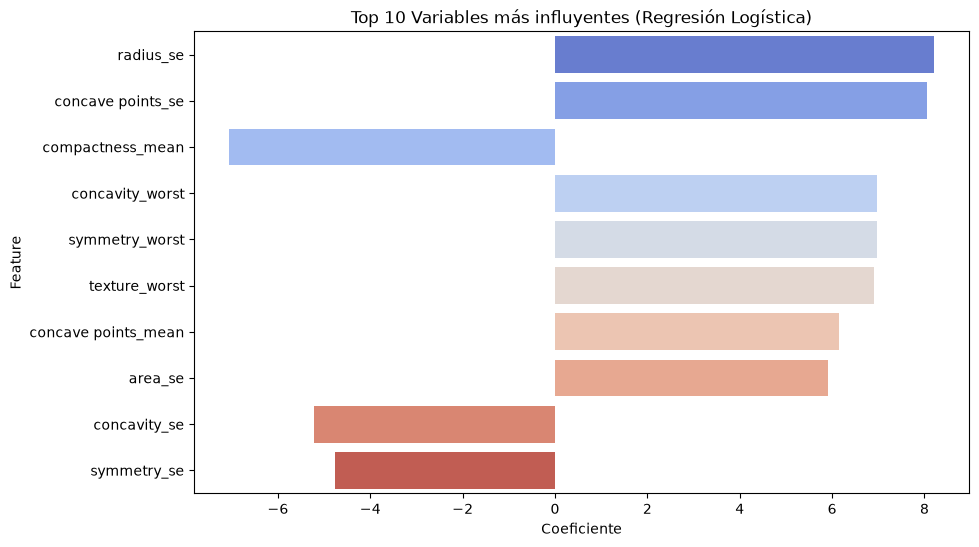

In [15]:
# 3. Importancia de Variables (Top 10 coeficientes absolutos)
coeficientes = pd.DataFrame({
    'Feature': X.columns,
    'Coeficiente': best_model.coef_[0],
    'Valor_Absoluto': np.abs(best_model.coef_[0])
}).sort_values(by='Valor_Absoluto', ascending=False).head(10)
plt.figure(figsize=(10,6))
sns.barplot(x='Coeficiente', y='Feature', data=coeficientes, palette='coolwarm')
plt.title('Top 10 Variables más influyentes (Regresión Logística)')
plt.show()

In [16]:
# Guardamos tanto el modelo como el scaler
joblib.dump(best_model, 'modelo_cancer_logreg.pkl')
joblib.dump(scaler, 'scaler_cancer.pkl')
print("✅ Modelo y Scaler guardados exitosamente.")

✅ Modelo y Scaler guardados exitosamente.
